In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py
import os
import mdtraj as md
from einops import rearrange, repeat, reduce
from omm import get_traj_from_tw
plt.style.use('rotskoff')
# rotskoff_cmap = mpl.colors.LinearSegmentedColormap.from_list("mycmap", ['#1B346C','#01ABE9','#F1F8F1',"#B12E3B"])
rotskoff_cmap = mpl.colors.LinearSegmentedColormap.from_list("mycmap", ['#1B346C','#01ABE9','#F1F8F1','#DB3A4B'])
rotskoff_cmap_2 = mpl.colors.LinearSegmentedColormap.from_list("mycmap", ['#FFFFFF', '#820000'])
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "Computer Modern Roman",
})
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"  # to avoid hdf5 file locking issues on shared filesystems
# point to latex
os.environ["PATH"] = "/usr/local/modules/latex/texlive/2024/bin/x86_64-linux:" + os.environ["PATH"]
# Check if latex is available, if not disable it+
import shutil
if shutil.which("latex") is None:
    plt.rcParams.update({
        "text.usetex": False,
    })
    print("LaTeX not found, disabling TeX rendering")
    print(f"Current PATH: {os.environ['PATH']}")
from openmm import unit

In [10]:
data_root_dir = "/data2/scratch/group_scratch/diff_likelihoods/trpcage/"
atomistic_traj_path = f"{data_root_dir}/trpcage_traj_all.hdf5"
fg_topology = md.load(f"{data_root_dir}/reference.pdb").topology
cg_topology = fg_topology.subset(fg_topology.select("(not element H) and (not name OXT)"))
with h5py.File(atomistic_traj_path, "r") as f:
    atomistic_traj = get_traj_from_tw(f, fg_topology, slice(None,None,10))
print(atomistic_traj)

<mdtraj.Trajectory with 302800 frames, 284 atoms, 20 residues, without unitcells>


In [11]:
seq = ""
for res in atomistic_traj.topology.residues:
    seq += res.code
    print(res.name)

print(seq)

ASP
ALA
TYR
ALA
GLN
TRP
LEU
LYS
ASP
GLY
GLY
PRO
SER
SER
GLY
ARG
PRO
PRO
PRO
SER
DAYAQWLKDGGPSSGRPPPS


In [3]:
pdb_folded = md.load(f"{data_root_dir}/reference.pdb")
pdb_folded_cg = pdb_folded.atom_slice(pdb_folded.topology.select("name CA or name C or name N"))
ca_indices = pdb_folded_cg.top.select("name CA")
dihedral_indices = [ca_indices[-4:]]
native_contact_indices = np.load(f"{data_root_dir}/native_contact_cg_indices.npy")


num_cg_atoms = cg_topology.n_atoms
def get_trpcage_reaction_coordinates(traj, cutoff=6):
    cg_traj = traj.atom_slice(traj.topology.select("name CA or name N or name C"))
    assert cg_traj.n_atoms == num_cg_atoms
    dihedrals = md.compute_dihedrals(cg_traj, dihedral_indices).reshape(-1)
    contacts = md.compute_distances(cg_traj, native_contact_indices) * 10
    contacts = (cutoff - contacts)
    contacts = (1 / (1 + np.exp( - 2 * (contacts + 0.75)))).mean(axis=1)
    # contacts = np.clip(contacts, 0, 1)
    # contacts = np.mean(contacts, axis=1)
    return np.stack([dihedrals, contacts], axis=1)

In [38]:
#save uniform samples from the trajectory to get starting points for CG simulations
num_start_pos = 128
indices = np.linspace(0, atomistic_traj.xyz.shape[0]-1, num_start_pos, dtype=int)
start_positions = atomistic_traj.slice(indices)

In [39]:
# # make the free energy landscape plot for the atomistic simulation
# atomistic_tica_coords = get_trpcage_reaction_coordinates(atomistic_traj)
# start_pos_tica_coords = atomistic_tica_coords[indices]
# fig, ax = plt.subplots( figsize=(8, 6))

# hb = ax.hexbin(atomistic_tica_coords[:,0], atomistic_tica_coords[:,1], gridsize=50, cmap=rotskoff_cmap.reversed(), norm=mpl.colors.LogNorm())
# ax.scatter(start_pos_tica_coords[:,0], start_pos_tica_coords[:,1], color='black', s=50, label='Starting Positions')
# ax.grid(False)
# ax.set_title("Trp-Cage Simulation", fontsize=20)
# ax.set_xlabel("TIC1", fontsize=16)
# ax.set_ylabel("TIC2", fontsize=16)
# fig.legend(fontsize=14, bbox_to_anchor=(1.15, 0.9))
# cb = fig.colorbar(hb, ax=ax)

In [40]:
# # choose uniformly spaced starting positions in tica space for CG simulations
# grid = torch.meshgrid(
#     torch.linspace(-5, 5, steps=20),
#     torch.linspace(-5, 5, steps=20),
#     indexing='ij'
# )
# grid_points = torch.stack(grid, dim=-1).view(-1, 2)
# # find the closest frames in tica space to these grid points
# from scipy.spatial import cKDTree
# tree = cKDTree(atomistic_tica_coords.numpy())
# distances, indices = tree.query(grid_points.numpy())
# # throw out points that are too far from any frame
# threshold = 0.5
# indices = indices[distances < threshold]
# print(f"Number of starting positions selected: {len(indices)}")


In [41]:
start_pos_array = atomistic_traj.xyz[indices]*10 # convert to angstroms
print(start_pos_array.shape)
# np.save("./trpcage_start_positions_grid.npy", start_pos_array)
np.save(f"{data_root_dir}/trpcage_start_positions_iid.npy", start_pos_array)
# save the above as a trajectory pdb
start_pos_traj = atomistic_traj[indices]
start_pos_traj.save(f"{data_root_dir}/trpcage_start_positions_iid.pdb")

(128, 284, 3)


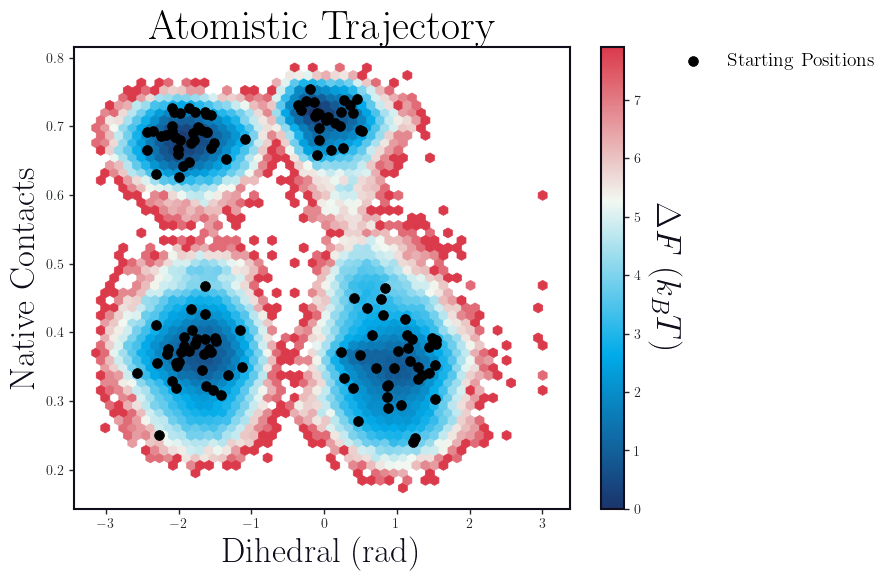

<Figure size 640x480 with 0 Axes>

In [42]:
def plot_free_energy_landscape(traj, colvar_fn, fig=None, ax=None):
    colvars = colvar_fn(traj)
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    dummy_fig, dummy_ax = plt.subplots()
    dummy_hb = dummy_ax.hexbin(colvars[:,0], colvars[:,1], gridsize=50, 
                cmap=rotskoff_cmap, C=np.ones(len(colvars)), reduce_C_function=lambda c: - np.log(np.sum(c)/len(colvars)))
    plt.clf()
    centers = dummy_hb.get_offsets()
    counts = dummy_hb.get_array()
    hb = ax.hexbin(centers[:,0], centers[:,1], C=counts - counts.min(), gridsize=50, cmap=rotskoff_cmap)


    return fig, ax, hb, colvars

fig, ax, hb, colvars = plot_free_energy_landscape(atomistic_traj, get_trpcage_reaction_coordinates)

ax.set_title("Atomistic Trajectory", fontsize=30)
ax.set_xlabel("Dihedral (rad)", fontsize=25)
ax.set_ylabel("Native Contacts", fontsize=25)
cb = fig.colorbar(hb, ax=ax)
cb.set_label(r"$\Delta F$ ($k_B T$)", fontsize=25, rotation=270, labelpad=30)

start_pos_cv = colvars[indices]
ax.scatter(start_pos_cv[:,0], start_pos_cv[:,1], color='black', s=50, label='Starting Positions')
fig.legend(fontsize=14, bbox_to_anchor=(1.15, 0.9))


In [59]:
experiment_dir = "/data2/scratch/group_scratch/diff_likelihoods/trpcage/boltz_results_trpcage_umbrella_v2_unbiased_overdamped/umbrella_3"
with h5py.File(f"{experiment_dir}/langevin_samples.hdf5", "r", ) as f:
    for key in f.keys():
        print(key, f[key].shape)
    # shape (timestep, batch_size, num_cg_particles, 3) in angstroms
    cg_positions = f["positions"][:]
    forces = f["forces"][:]

# burn_in = cg_positions.shape[0] // 5
burn_in = 0

cg_traj_all = md.Trajectory(
    xyz=rearrange(cg_positions, "step batch atom xyz -> (batch step) atom xyz")/10, # convert to nm
    topology=cg_topology,
    )

accepted (0, 128)
energies (0, 128)
forces (961, 128, 147, 3)
positions (961, 128, 147, 3)


/tmp/ipykernel_3165296/3124506511.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(fontsize=14, bbox_to_anchor=(1.15, 0.9))


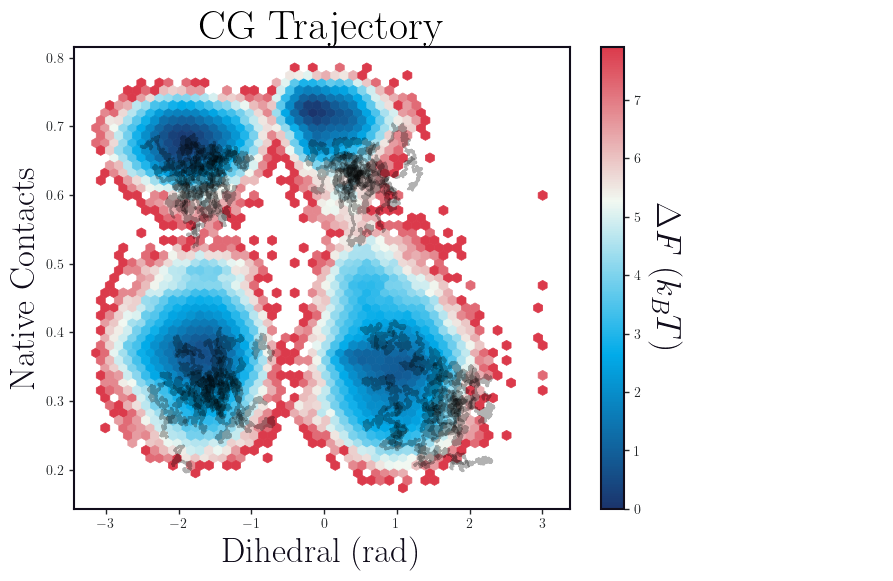

<Figure size 640x480 with 0 Axes>

In [60]:

fig, ax, hb, colvars = plot_free_energy_landscape(atomistic_traj, get_trpcage_reaction_coordinates)

ax.set_title("CG Trajectory", fontsize=30)
ax.set_xlabel("Dihedral (rad)", fontsize=25)
ax.set_ylabel("Native Contacts", fontsize=25)
cb = fig.colorbar(hb, ax=ax)
cb.set_label(r"$\Delta F$ ($k_B T$)", fontsize=25, rotation=270, labelpad=30)

cg_colvars = get_trpcage_reaction_coordinates(cg_traj_all)
cg_colvars_batched = rearrange(cg_colvars, "(batch step) cv -> step batch cv", batch=cg_positions.shape[1])
for i in range(cg_colvars_batched.shape[1]):
    ax.plot(cg_colvars_batched[:,i,0], cg_colvars_batched[:,i,1], color='black', alpha=0.3)

# ax.scatter(cg_colvars_batched[0,:,0], cg_colvars_batched[0,:,1], color='black', s=50, label='Starting Positions')

fig.legend(fontsize=14, bbox_to_anchor=(1.15, 0.9))


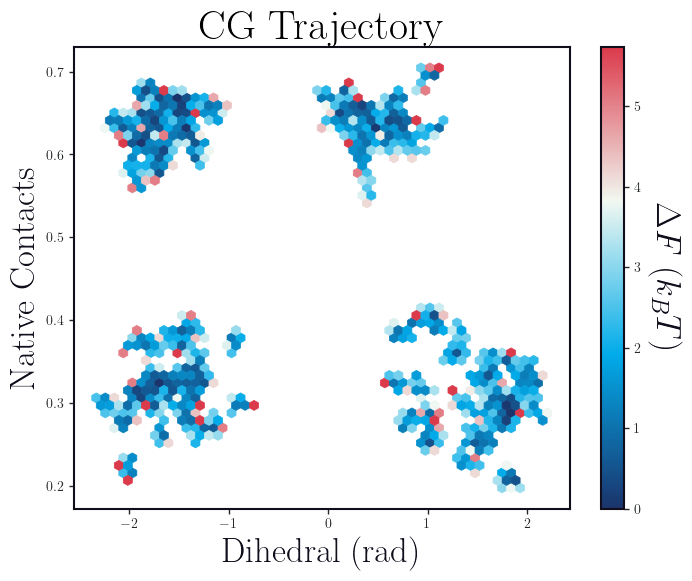

<Figure size 640x480 with 0 Axes>

In [54]:
fig, ax, hb, colvars = plot_free_energy_landscape(cg_traj_all, get_trpcage_reaction_coordinates)

ax.set_title("CG Trajectory", fontsize=30)
ax.set_xlabel("Dihedral (rad)", fontsize=25)
ax.set_ylabel("Native Contacts", fontsize=25)
cb = fig.colorbar(hb, ax=ax)
cb.set_label(r"$\Delta F$ ($k_B T$)", fontsize=25, rotation=270, labelpad=30)


# fig.legend(fontsize=14, bbox_to_anchor=(1.15, 0.9))

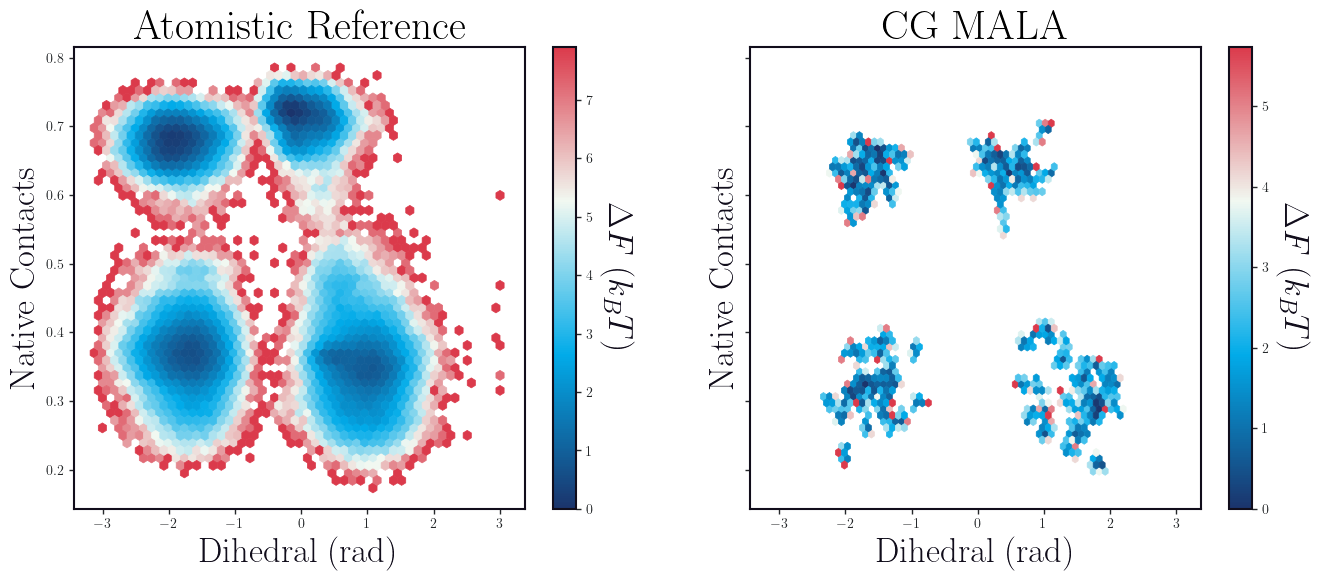

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [58]:
def plot_free_energy_landscape_multiple(traj_list, colvar_fn, shared_colorbar_scale=True):
    num_cols = len(traj_list)

    fig, ax = plt.subplots(1, num_cols, figsize=(8*num_cols, 6), sharex=True, sharey=True)
    all_counts = []
    all_centers = []
    hb = []
    for i, traj in enumerate(traj_list):
        colvars = colvar_fn(traj)

        dummy_fig, dummy_ax = plt.subplots()
        dummy_hb = dummy_ax.hexbin(colvars[:,0], colvars[:,1], gridsize=50, 
                    cmap=rotskoff_cmap, C=np.ones(len(colvars)), reduce_C_function=lambda c: - np.log(np.sum(c)/len(colvars)))
        plt.clf()
        all_counts.append(dummy_hb.get_array())
        all_centers.append(dummy_hb.get_offsets())
    
    # Normalize each plot relative to its own minimum
    normalized_counts = [counts - counts.min() for counts in all_counts]
    
    if shared_colorbar_scale:
        # Use consistent colorbar scale across all plots
        vmin = 0
        vmax = max([counts.max() for counts in normalized_counts])
        
        for i in range(num_cols):
            counts = normalized_counts[i]
            centers = all_centers[i]
            hb.append(ax[i].hexbin(centers[:,0], centers[:,1], C=counts, gridsize=50, 
                                  cmap=rotskoff_cmap, vmin=vmin, vmax=vmax))
    else:
        # Each plot gets its own independent colorbar scale
        for i in range(num_cols):
            counts = normalized_counts[i]
            centers = all_centers[i]
            hb.append(ax[i].hexbin(centers[:,0], centers[:,1], C=counts, gridsize=50, 
                                  cmap=rotskoff_cmap))

    return fig, ax, hb

fig, ax, hb = plot_free_energy_landscape_multiple([atomistic_traj, cg_traj_all], get_trpcage_reaction_coordinates, shared_colorbar_scale=False)

ax[0].set_title("Atomistic Reference", fontsize=30)
ax[0].set_xlabel("Dihedral (rad)", fontsize=25)
ax[0].set_ylabel("Native Contacts", fontsize=25)
cb0 = fig.colorbar(hb[0], ax=ax[0])
cb0.set_label(r"$\Delta F$ ($k_B T$)", fontsize=25, rotation=270, labelpad=30)
ax[1].set_title("CG MALA", fontsize=30)
ax[1].set_xlabel("Dihedral (rad)", fontsize=25)
ax[1].set_ylabel("Native Contacts", fontsize=25)
cb1 = fig.colorbar(hb[1], ax=ax[1])
cb1.set_label(r"$\Delta F$ ($k_B T$)", fontsize=25, rotation=270, labelpad=30)

In [56]:
cg_traj_all[:1000].center_coordinates().save_pdb("cg_trpcage_mala.pdb")